In [1]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

In [ ]:
# ==========================================================
# Dense Coding using 6 qubit Cluster State
# ==========================================================
qc = QuantumCircuit(6,6)

# ----------------------------------------------------------
# Cluster State Preparation
# ----------------------------------------------------------

qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.h(3)
qc.cx(3, 4)
qc.cx(3, 5)

qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

In [3]:
# ----------------------------------------------------------
# Alice Encoding
# ----------------------------------------------------------
message = "100111"  

if message == "000000":
    pass

elif message == "000001":
    qc.x(5)

elif message == "000101":
    qc.y(5)

elif message == "000100":
    qc.z(5)
#------------------------------------------------------------
elif message == "011000":
    qc.x(0)

elif message == "011001":
    qc.x(0)
    qc.x(5)

elif message == "011101":
    qc.x(0)
    qc.y(5)

elif message == "011100":
    qc.x(0)
    qc.z(5)
#------------------------------------------------------------
elif message == "111000":
    qc.y(0)

elif message == "111001":
    qc.y(0)
    qc.x(5)

elif message == "111101":
    qc.y(0)
    qc.y(5)

elif message == "111100":
    qc.y(0)
    qc.z(5)
#------------------------------------------------------------
elif message == "100000":
    qc.z(0)

elif message == "100001":
    qc.z(0)
    qc.x(5)

elif message == "100101":
    qc.z(0)
    qc.y(5)

elif message == "100100":
    qc.z(0)
    qc.z(5)
#------------------------------------------------------------
elif message == "000011":
    qc.x(3)
elif message == "000010":
    qc.x(3)
    qc.x(5)

elif message == "000110":
    qc.x(3)
    qc.y(5)

elif message == "000111":
    qc.x(3)
    qc.z(5)
#------------------------------------------------------------
elif message == "011011":
    qc.x(0)
    qc.x(3)

elif message == "011010":
    qc.x(0)
    qc.x(3)
    qc.x(5)

elif message == "011110":
    qc.x(0)
    qc.x(3)
    qc.y(5)

elif message == "011111":
    qc.x(0)
    qc.x(3)
    qc.z(5)
#------------------------------------------------------------
elif message == "111011":
    qc.y(0)
    qc.x(3)

elif message == "111010":
    qc.y(0)
    qc.x(3)
    qc.x(5)

elif message == "111110":
    qc.y(0)
    qc.x(3)
    qc.y(5)

elif message == "111111":
    qc.y(0)
    qc.x(3)
    qc.z(5)
#------------------------------------------------------------
elif message == "100011":
    qc.z(0)
    qc.x(3)

elif message == "100010":
    qc.z(0)
    qc.x(3) 
    qc.x(5)

elif message == "100110":
    qc.z(0)
    qc.x(3)
    qc.y(5)

elif message == "100111":
    qc.z(0)
    qc.x(3)
    qc.z(5)
#------------------------------------------------------------
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=6, num_clbits=0, params=[]), qubits=(<Qubit register=(6, "q"), index=0>, <Qubit register=(6, "q"), index=1>, <Qubit register=(6, "q"), index=2>, <Qubit register=(6, "q"), index=3>, <Qubit register=(6, "q"), index=4>, <Qubit register=(6, "q"), index=5>), clbits=())

In [4]:
# ----------------------------------------------------------
# Bob Decoding
# ----------------------------------------------------------


qc.cx(3,5)
qc.cx(3,4)
qc.cx(0,2)
qc.cx(0,1)
qc.barrier()

qc.h(0)
qc.h(3)
qc.barrier()

qc.measure([0,1,2,3,4,5],[0,1,2,3,4,5])

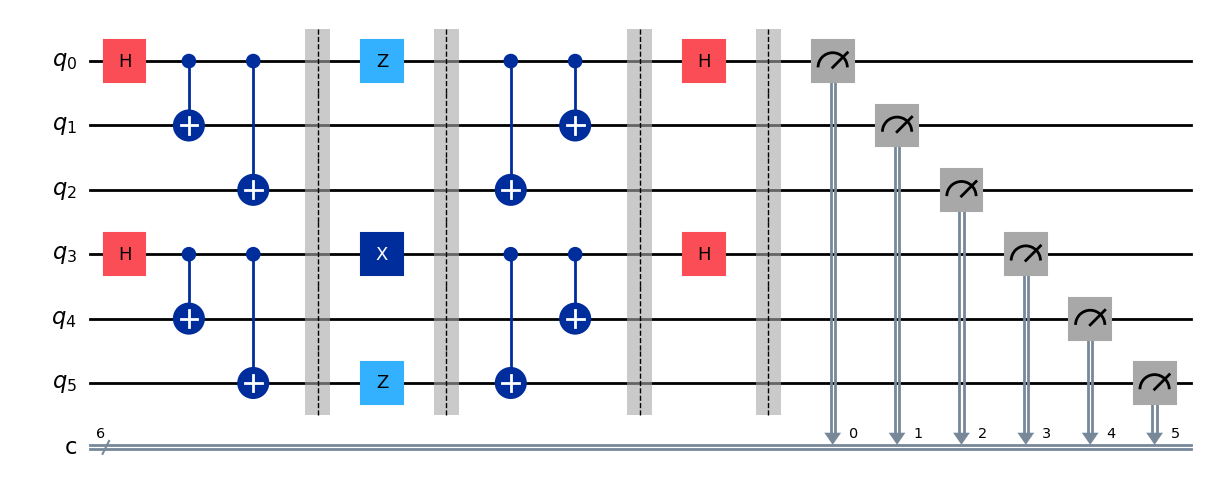

In [5]:
qc.draw(output="mpl")

In [6]:
print(qc.depth())

8


{'000000': 0, '000001': 0, '000010': 0, '000011': 0, '000100': 0, '000101': 0, '000110': 0, '000111': 0, '001000': 0, '001001': 0, '001010': 0, '001011': 0, '001100': 0, '001101': 0, '001110': 0, '001111': 0, '010000': 0, '010001': 0, '010010': 0, '010011': 0, '010100': 0, '010101': 0, '010110': 0, '010111': 0, '011000': 0, '011001': 0, '011010': 0, '011100': 0, '011101': 0, '011110': 0, '011111': 0, '100000': 0, '100001': 0, '100010': 0, '100011': 0, '100100': 0, '100101': 0, '100110': 0, '100111': 0, '101000': 0, '101001': 0, '101010': 0, '101011': 0, '101100': 0, '101101': 0, '101110': 0, '101111': 0, '110000': 0, '110001': 0, '110010': 0, '110011': 0, '110100': 0, '110101': 0, '110110': 0, '110111': 0, '111000': 0, '111001': 4096, '111010': 0, '111011': 0, '111100': 0, '111101': 0, '111110': 0, '111111': 0}


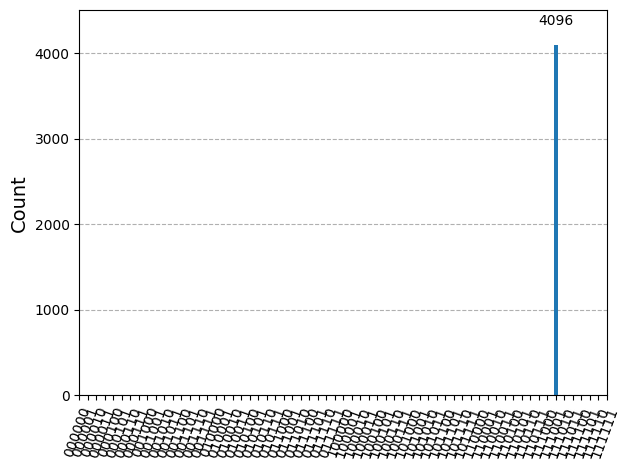

In [ ]:
simulator = Aer.get_backend('qasm_simulator')

result = simulator.run(qc, shots=4096).result()
counts = result.get_counts()

all_states = ['000000', '000001', '000010','000011','000100', '000101', '000110','000111','001000', '001001', '001010', '001011', '001100', '001101', '001110', '001111', '010000', '010001','010010','010011','010100','010101', '010110','010111', '011000', '011001', '011010', '011100', '011101', '011110', '011111', '100000', '100001', '100010','100011','100100', '100101','100110','100111', '101000', '101001','101010','101011', '101100', '101101', '101110','101111','110000', '110001', '110010','110011','110100','110101','110110','110111', '111000', '111001', '111010','111011','111100', '111101', '111110', '111111']
counts_complete = {state: counts.get(state, 0) for state in all_states}

print(counts_complete)

plot_histogram(counts_complete)

In [ ]:
import numpy as np
from itertools import product

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

# ==========================================================
# Prepare 6-qubit Cluster State
# ==========================================================

def cluster6():

    qc = QuantumCircuit(6)

    # Preparation

    qc.h(0)
    qc.h(3)

    qc.cx(0,1)
    qc.cx(0,2)

    qc.cx(3,4)
    qc.cx(3,5)

    return qc


base = cluster6()

# ==========================================================
# Alice possesses qubits
# q0, q3, q5
# ==========================================================

alice = [0,3,5]

paulis = ['I','X','Y','Z']

labels = []
encoded_states = []

# ==========================================================
# Generate all 64 encoding operators
# ==========================================================

for p0, p1, p2 in product(paulis, repeat=3):

    qc = base.copy()

    if p0 != 'I':
        getattr(qc, p0.lower())(alice[0])

    if p1 != 'I':
        getattr(qc, p1.lower())(alice[1])

    if p2 != 'I':
        getattr(qc, p2.lower())(alice[2])

    psi = Statevector.from_instruction(qc)

    encoded_states.append(psi.data)

    labels.append(p0+p1+p2)

N = len(encoded_states)

print("Total Encoded States =", N)

Total Encoded States = 64


In [9]:
G = np.zeros((N,N), dtype=complex)

for i in range(N):
    for j in range(N):

        G[i,j] = np.vdot(
            encoded_states[i],
            encoded_states[j]
        )

print("Gram Matrix Computed.")

Gram Matrix Computed.


In [10]:
if np.allclose(G, np.eye(N), atol=1e-10):

    print("\nAll 64 encoded states are mutually orthogonal.")

else:

    print("\nAll Encoded states are NOT mutually orthogonal.")


All Encoded states are NOT mutually orthogonal.


In [11]:
print("\n======================================================")
print("Non-Orthogonal Pairs")
print("======================================================\n")

count = 0

for i in range(N):

    for j in range(i+1,N):

        overlap = np.vdot(
            encoded_states[i],
            encoded_states[j]
        )

        if abs(overlap) > 1e-10:

            print(labels[i], "<->", labels[j])

            print("Overlap =", overlap)

            print()

            count += 1

print("Total Non-Orthogonal Pairs =", count)


Non-Orthogonal Pairs

III <-> IZZ
Overlap = (0.9999999999999996+0j)

IIX <-> IZY
Overlap = 0.9999999999999996j

IIY <-> IZX
Overlap = -0.9999999999999996j

IIZ <-> IZI
Overlap = (0.9999999999999996+0j)

IXI <-> IYZ
Overlap = 0.9999999999999996j

IXX <-> IYY
Overlap = (-0.9999999999999996+0j)

IXY <-> IYX
Overlap = (0.9999999999999996+0j)

IXZ <-> IYI
Overlap = 0.9999999999999996j

XII <-> XZZ
Overlap = (0.9999999999999996+0j)

XIX <-> XZY
Overlap = 0.9999999999999996j

XIY <-> XZX
Overlap = -0.9999999999999996j

XIZ <-> XZI
Overlap = (0.9999999999999996+0j)

XXI <-> XYZ
Overlap = 0.9999999999999996j

XXX <-> XYY
Overlap = (-0.9999999999999996+0j)

XXY <-> XYX
Overlap = (0.9999999999999996+0j)

XXZ <-> XYI
Overlap = 0.9999999999999996j

YII <-> YZZ
Overlap = (0.9999999999999996+0j)

YIX <-> YZY
Overlap = 0.9999999999999996j

YIY <-> YZX
Overlap = -0.9999999999999996j

YIZ <-> YZI
Overlap = (0.9999999999999996+0j)

YXI <-> YYZ
Overlap = 0.9999999999999996j

YXX <-> YYY
Overlap = (-0.999

In [12]:
print("\n======================================================")
print("Orthogonal Pairs")
print("======================================================\n")

count = 0

for i in range(N):

    for j in range(i+1,N):

        overlap = np.vdot(
            encoded_states[i],
            encoded_states[j]
        )

        if abs(overlap) <= 1e-10:

            print(labels[i], "<->", labels[j])

            count += 1

print("Total Orthogonal Pairs =", count)


Orthogonal Pairs

III <-> IIX
III <-> IIY
III <-> IIZ
III <-> IXI
III <-> IXX
III <-> IXY
III <-> IXZ
III <-> IYI
III <-> IYX
III <-> IYY
III <-> IYZ
III <-> IZI
III <-> IZX
III <-> IZY
III <-> XII
III <-> XIX
III <-> XIY
III <-> XIZ
III <-> XXI
III <-> XXX
III <-> XXY
III <-> XXZ
III <-> XYI
III <-> XYX
III <-> XYY
III <-> XYZ
III <-> XZI
III <-> XZX
III <-> XZY
III <-> XZZ
III <-> YII
III <-> YIX
III <-> YIY
III <-> YIZ
III <-> YXI
III <-> YXX
III <-> YXY
III <-> YXZ
III <-> YYI
III <-> YYX
III <-> YYY
III <-> YYZ
III <-> YZI
III <-> YZX
III <-> YZY
III <-> YZZ
III <-> ZII
III <-> ZIX
III <-> ZIY
III <-> ZIZ
III <-> ZXI
III <-> ZXX
III <-> ZXY
III <-> ZXZ
III <-> ZYI
III <-> ZYX
III <-> ZYY
III <-> ZYZ
III <-> ZZI
III <-> ZZX
III <-> ZZY
III <-> ZZZ
IIX <-> IIY
IIX <-> IIZ
IIX <-> IXI
IIX <-> IXX
IIX <-> IXY
IIX <-> IXZ
IIX <-> IYI
IIX <-> IYX
IIX <-> IYY
IIX <-> IYZ
IIX <-> IZI
IIX <-> IZX
IIX <-> IZZ
IIX <-> XII
IIX <-> XIX
IIX <-> XIY
IIX <-> XIZ
IIX <-> XXI
IIX <-> XXX
IIX <-> X

In [ ]:
np.set_printoptions(
    threshold=np.inf,
    linewidth=250, 
    precision=3,
    suppress=True
)

print(np.abs(G))

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.

In [14]:
import networkx as nx
import numpy as np

# -------------------------------------------------
# Build orthogonality graph
# -------------------------------------------------

Ggraph = nx.Graph()

# add 64 vertices
for i in range(N):
    Ggraph.add_node(i)

# connect orthogonal pairs
for i in range(N):
    for j in range(i+1, N):

        overlap = abs(np.vdot(encoded_states[i], encoded_states[j]))

        if overlap < 1e-10:
            Ggraph.add_edge(i, j)

print("Vertices =", Ggraph.number_of_nodes())
print("Edges =", Ggraph.number_of_edges())

Vertices = 64
Edges = 1984


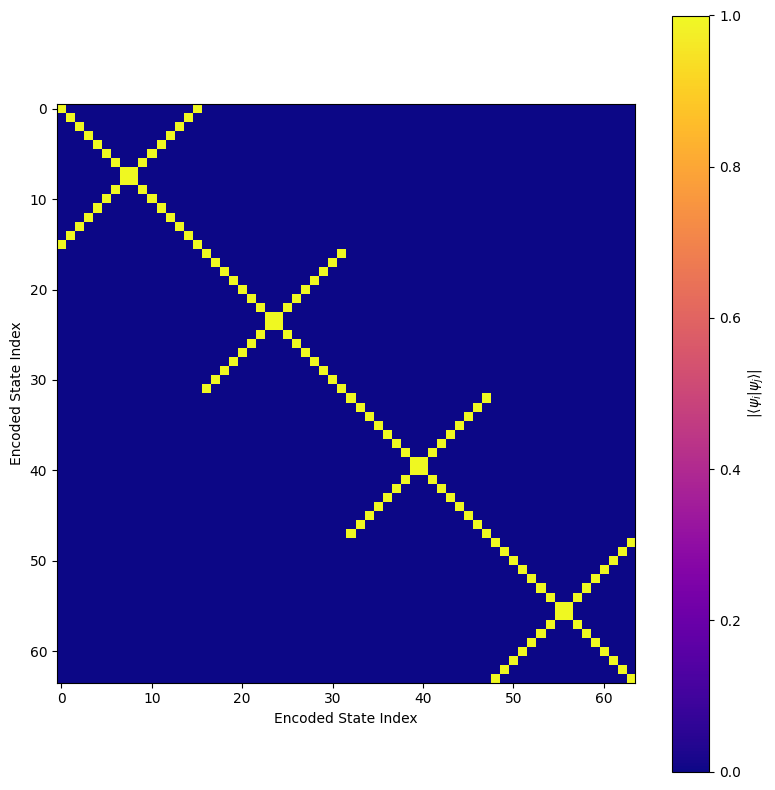

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(8,8))

plt.imshow(
    np.abs(G),
    cmap='plasma',
    interpolation='nearest'
)

plt.colorbar(label=r'$|\langle\psi_i|\psi_j\rangle|$')

#plt.title("Gram Matrix of Encoded States")

plt.xlabel("Encoded State Index")
plt.ylabel("Encoded State Index")

plt.tight_layout()
plt.show()

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city
import matplotlib.pyplot as plt

qc = QuantumCircuit(6)

# -------------------------------
# CLUSTER PREPARATION
# -------------------------------

qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.h(3)
qc.cx(3, 4)
qc.cx(3, 5)

# -------------------------------

rho = DensityMatrix.from_instruction(qc)

fig = plot_state_city(rho)

plt.show()

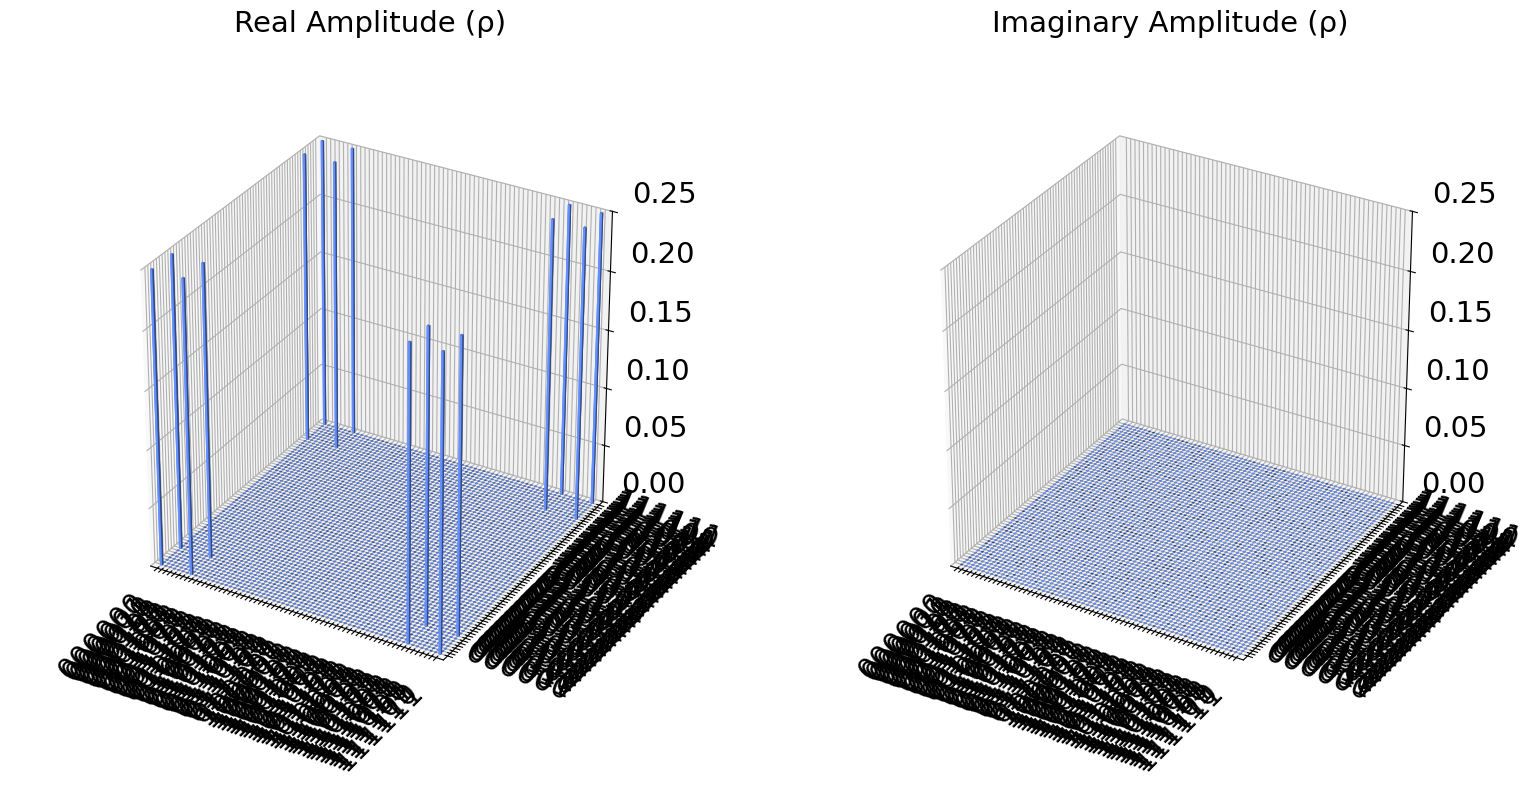

In [17]:
display(fig)

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

tol = 1e-10

graph = nx.Graph()

graph.add_nodes_from(range(64))

for i in range(64):
    for j in range(i+1,64):

        if abs(G[i,j]) < tol:
            graph.add_edge(i,j)

print("Vertices :",graph.number_of_nodes())
print("Edges    :",graph.number_of_edges())

Vertices : 64
Edges    : 1984


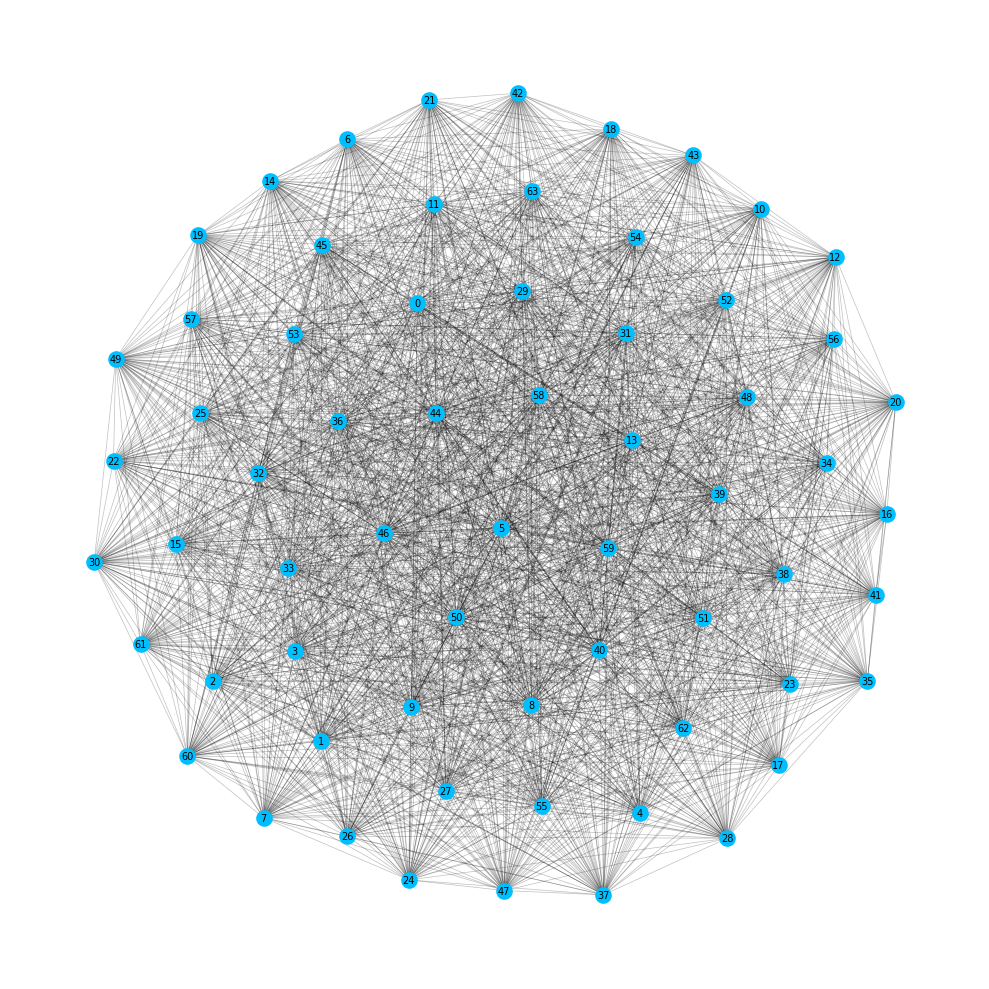

In [19]:
plt.figure(figsize=(10,10))

pos = nx.spring_layout(
    graph,
    seed=1,
    k=0.35
)

nx.draw_networkx_nodes(
    graph,
    pos,
    node_size=120,
    node_color='deepskyblue'
)

nx.draw_networkx_edges(
    graph,
    pos,
    alpha=0.25,
    width=0.5
)

nx.draw_networkx_labels(
    graph,
    pos,
    font_size=7
)

#plt.title("Orthogonality Graph of 64 Encoded Cluster States")

plt.axis("off")

plt.tight_layout()

plt.show()